# Dataset
[Link do kaggla](https://www.kaggle.com/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images)

# Notatnik :-)
### Tutaj możemy zapisywać czego ciekawego się nauczyliśmy XD
* `os.walk(path)` - wysyłamy przewodnika, który "oprowadza" nas po wskazanym folderze. Zagłębia się tak długo, aż sprawdzi każdy podfolder. W każdym kroku(folderze) dostajemy raport (obecny_folder, podfoldery, pliki w tym folderze)
* `path.iterdir()` - metoda z biblioteki Pathlib. Pokaże zawartość(podfoldery i/lub pliki) podanego folderu **BEZ ZAGŁĘBIANIA SIĘ**
* `plt.subplots(rows, cols)` - kilka zdjec obok siebie
```py
fig, axes = plt.subplots(rows, cols) # Przygotownie ramki (`axes` to lista jeszcze pustych ramek)
for ax, img in zip(axes, samples):   # Bierze pierwsze okienko i przypisuje mu pierwsze zdjęci, potem drugie okienko z drugim zdjęciem itd... `zip` działa jak suwak
  ax.imshow(Image.open(img))         # Faktyczne wstawienie obrazka do ramki
```
* Augmentacja to sztuczne powiększanie datasetu przez losowe transformacje zdjęć. Dla danych treningowych stosujemy losowe obroty, odbicia, zmiany jasności – model widzi za każdym razem trochę inny obraz, co zapobiega uczeniu się na pamięć. Dla zbioru testowego nie augmentujemy, bo chcemy ocenić model na prawdziwych danych.

* `ImageFolder` Automatycznie skanuje strukturę folderów. Folder benign/ → etykieta 0, folder malignant/ → etykieta 1. Każde zdjęcie dostaje automatycznie właściwą etykietę na podstawie folderu, w którym się znajduje.

* `DataLoader` Podaje modelowi dane batch po batchu, dla danych treningowych kolejność jest losowa `shuffle = True`, a dla treningowych nie, bo chcemy powatarzalne wyniki.

# Importy

In [ ]:
import kagglehub
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import numpy as np

from pathlib import Path

# Device-agnostic code

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# PART 1 - Eksploaracja danych

### Import datasetu z kaggla

In [ ]:
base_path = kagglehub.dataset_download("hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images")

print("Path to dataset files:", base_path)

Using Colab cache for faster access to the 'melanoma-skin-cancer-dataset-of-10000-images' dataset.
Path to dataset files: /kaggle/input/melanoma-skin-cancer-dataset-of-10000-images


### "Oprowadzenie" po zaimportowanym folderze

In [ ]:
for root,dirs,files in os.walk(base_path):
  print(root)

/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/benign
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test/malignant
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train/benign
/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train/malignant


### Przygotowanie dokładnych, osobnych ścieżek dla danych treningowych i testowych

In [ ]:
train_path = Path(base_path) / 'melanoma_cancer_dataset' / 'train'
test_path = Path(base_path) / 'melanoma_cancer_dataset' / 'test'

### Policzenie próbek

In [ ]:
for subfolder in train_path.iterdir():
      print(f"train/{subfolder.name}: {len(list(subfolder.iterdir()))}")

for subfolder in test_path.iterdir():
    print(f"test/{subfolder.name}: {len(list(subfolder.iterdir()))}")

train/benign: 5000
train/malignant: 4605
test/benign: 500
test/malignant: 500


### Wizualizacja losowych próbek

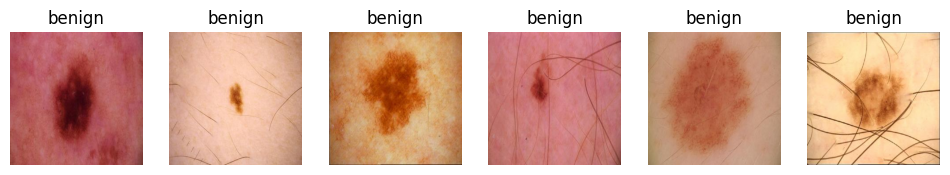

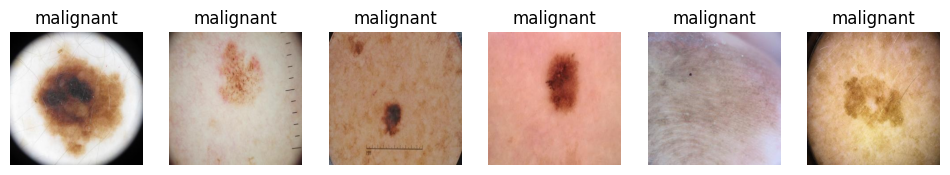

In [ ]:
def show_grid(split_path, class_name, n=6):
    cls_path = Path(split_path) / class_name
    samples = random.sample(list(cls_path.iterdir()), n)

    fig, axes = plt.subplots(1, n, figsize=(12, 3))
    for ax, p in zip(axes, samples):
        ax.imshow(Image.open(p).convert("RGB"))
        ax.set_title(class_name)
        ax.axis("off")
    plt.show()

show_grid(train_path, "benign")
show_grid(train_path, "malignant")

### TO-DO: Z wykorzystaniem `torchvision.transforms` stwórz dwa pipeliny transformacji: train_transforms i test_trainsforms

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### TO-DO: Za pomocą gotowej funkcji `ImageFolder` z `torchvision.datasets` stwórz train_dataset i test_dataset. (Tip: wyżej masz stworzone już test_path i train_path, które ci się przyda)

In [ ]:
train_dataset = datasets.ImageFolder(
    root=train_path,
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root=test_path,
    transform=test_transforms
)

print(f"Klasy: {train_dataset.classes}")
print(f"Etykiety: {train_dataset.class_to_idx}")
print(f"Próbki treningowe: {len(train_dataset)}")
print(f"Próbki testowe: {len(test_dataset)}")

Klasy: ['benign', 'malignant']
Etykiety: {'benign': 0, 'malignant': 1}
Próbki treningowe: 9605
Próbki testowe: 1000


### TO-DO: Za pomocą funkcjonalności z `torch.utils.data` utwórz train_loader i test_loader dla przedchwilą stworzonych datasetów. Daj mu odpowiednie parametry

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print(f"Liczba batchów treningowych: {len(train_loader)}")
print(f"Liczba batchów testowych: {len(test_loader)}")

Liczba batchów treningowych: 301
Liczba batchów testowych: 32


### TO-DO: Zaprezentuj, że Dataloader działa i wypluwa zdjęcia batchami

Kształt batcha obrazów: torch.Size([32, 3, 224, 224])
Kształt batcha etykiet: torch.Size([32])
Etykiety w batchu: tensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 1, 0, 1, 0])


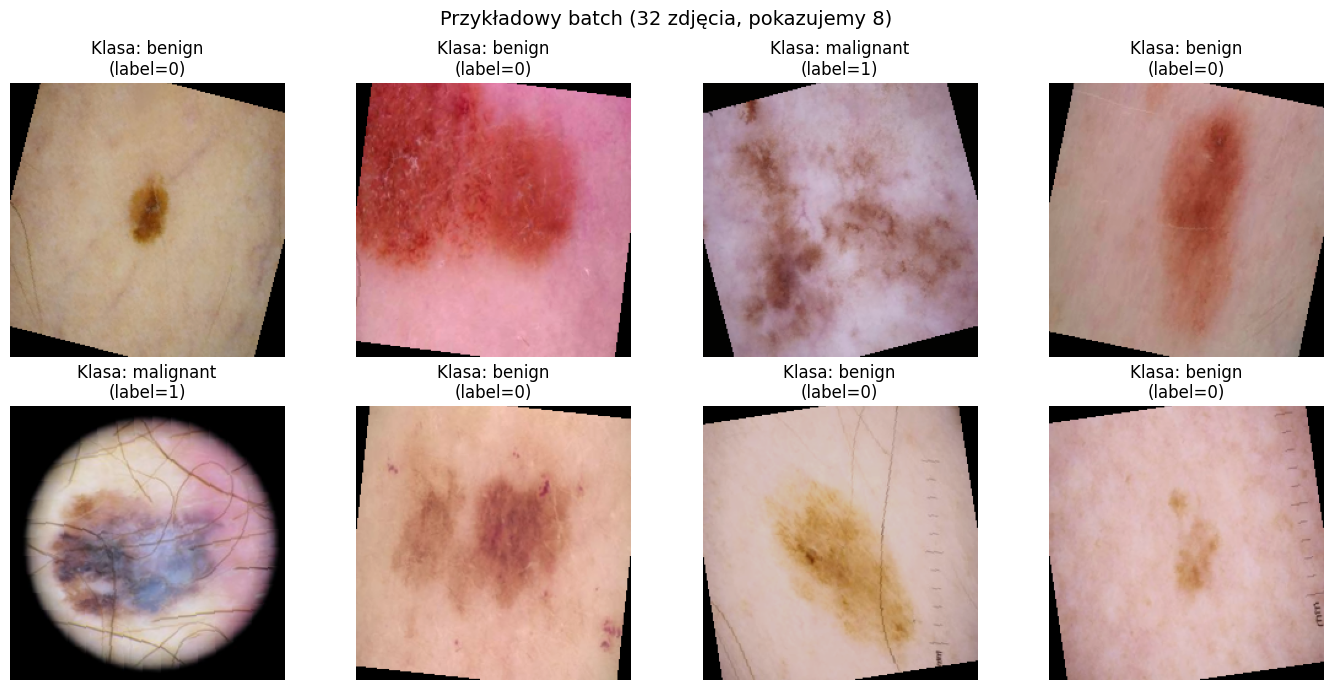

In [ ]:
images, labels = next(iter(train_loader))

print(f"Kształt batcha obrazów: {images.shape}")

print(f"Kształt batcha etykiet: {labels.shape}")

print(f"Etykiety w batchu: {labels}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

class_names = train_dataset.classes

for i, ax in enumerate(axes):
    img = denormalize(images[i])
    ax.imshow(img)
    ax.set_title(f"Klasa: {class_names[labels[i]]}\n(label={labels[i].item()})")
    ax.axis("off")

plt.suptitle(f"Przykładowy batch (32 zdjęcia, pokazujemy 8)", fontsize=14)
plt.tight_layout()
plt.show()